In [12]:
# load module
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger


from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet , EncoderNormalizer , GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

#import tensorflow as tf 
import tensorboard as tb 
#tf.io.gfile = tb.compat.tensorflow_stub.io.gfile

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'
#plt.rcParams['font.sans-serif'] = ['NanumGothic.ttf', 'sans-serif']

def moving_average_alpha(df: pd.DataFrame, unit: float):
    '''
    training datset에 ewma를 적용하는 함수 , unit = 0.3 or 0.4
    '''
    ret_df = pd.DataFrame()
    max_value = df['count'].max()
    # forward df
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        inv_dong_df = df[df['h_dong'] == dong][::-1]
        dong_df['count'] = dong_df['count'].ewm(alpha = unit).mean()
        for_ewma = dong_df['count'].ewm(alpha = unit).mean()
        back_ewma = inv_dong_df['count'].ewm(alpha = unit).mean()

        ewma = (for_ewma + back_ewma)/2 
        df['count'][dong_df.index] = ewma 
    df['count'] = df['count']  /  df['count'].max() * (max_value)
    
    #print(max_value , df['count'].max())
    return df

def data_processing(path : str  , unit : float):
    # path  : 데이터가 저장된 경로
    # unit  : ewma의 unit
    
    data = pd.read_csv(path)    
    # 사용하는 column만 선택
    data = data[['REG_DTIME', 'h_dong', 'count', 'pops', 'windspd','humid', 'temp', 'precip_form', 'precip', 'isHoliday']]
    data['REG_DTIME'] = pd.to_datetime(data['REG_DTIME'])
    data['DOW'] = data['REG_DTIME'].dt.dayofweek
    data['HOD'] = data['REG_DTIME'].dt.hour
    data['MOY'] = data['REG_DTIME'].dt.month
    # time_idx 시간을 고유하게 표현(윤년)
    #for x , y in enumerate(data['REG_DTIME'].unique()):
    #    t_data_index = data[data['REG_DTIME'] == y].index
    #    data.loc[t_data_index , 'time_idx'] = x
    data["time_idx"] =  \
    data["REG_DTIME"].dt.year * 365*24 + \
    data["REG_DTIME"].dt.day_of_year * 24  + \
    data["REG_DTIME"].dt.hour 
    data["time_idx"] -= data["time_idx"].min()
    # trainer에 넣기 위해서 category로 만들기
    data['h_dong'] = data['h_dong'].astype(str)
    data['DOW'] = data['DOW'].astype(str)
    data['HOD'] = data['HOD'].astype(str)
    data['MOY'] = data['MOY'].astype(str)
    data['precip_form'] = data['precip_form'].astype(str)
    data['isHoliday'] = data['isHoliday'].astype(str)
    # ewma 적용
    if unit == 0:
        return data
    else:
        data = moving_average_alpha(data,unit)
        return data


/home/nplab/.local/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/nplab/.local/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIlEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  warn(f"Failed to load image Python extension: {e}")
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will n

In [31]:
train = data_processing('../train.csv', 0.4)
test = data_processing('../test.csv', 0.4)
dong = '강남동'

In [55]:
def check_count(train, test , dong):
    cut_off = test['time_idx'].max()
    train = train[train['time_idx'] < cut_off]
    dong_train = train[train['h_dong'] ==dong]
    dong_train.reset_index(inplace=True)

    test = test[test['time_idx'] < cut_off]
    dong_test = test[test['h_dong'] == dong]
    dong_test.reset_index(inplace=True)
    
    
    plt.figure(figsize=(25,5))
    plt.plot(dong_train['count'], label = 'train data 2021년')
    plt.plot(dong_test['count'] , label = 'test data 2022년')
    plt.title(f'{dong} 1월 1일 ~ 2월 27일' , fontsize=20)
    plt.legend()

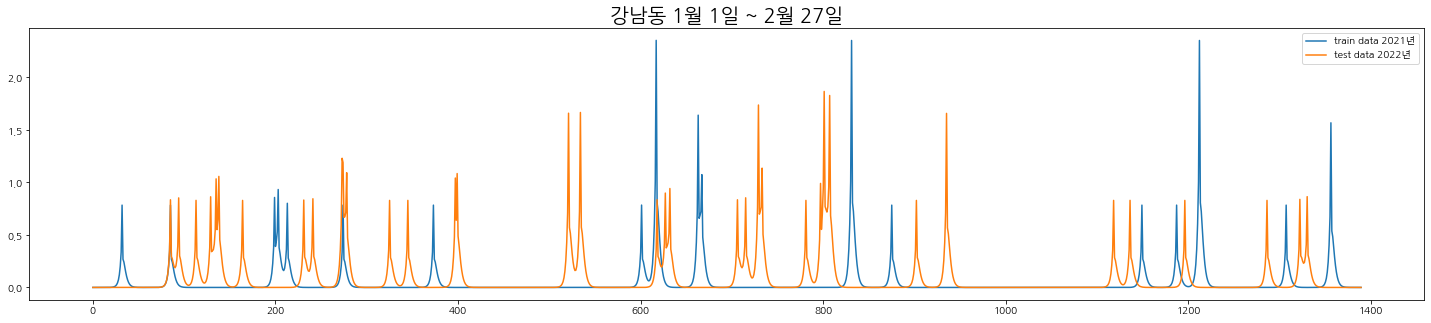

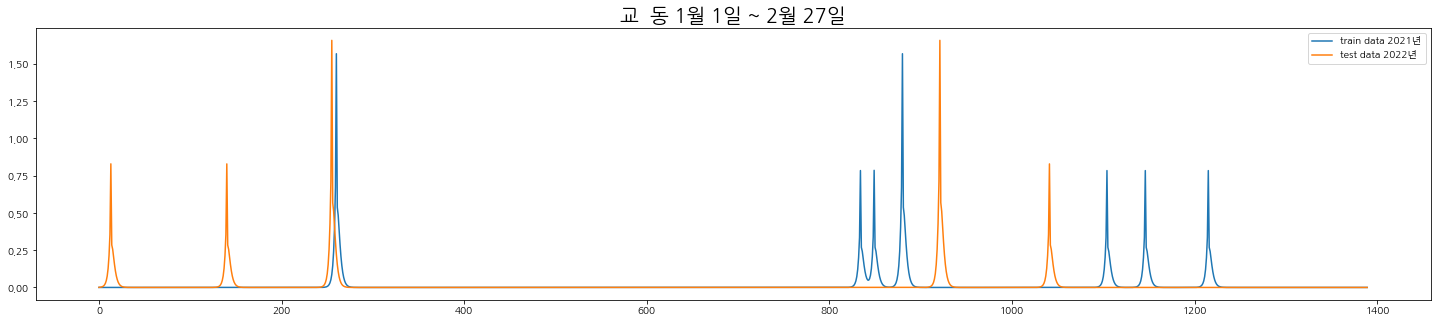

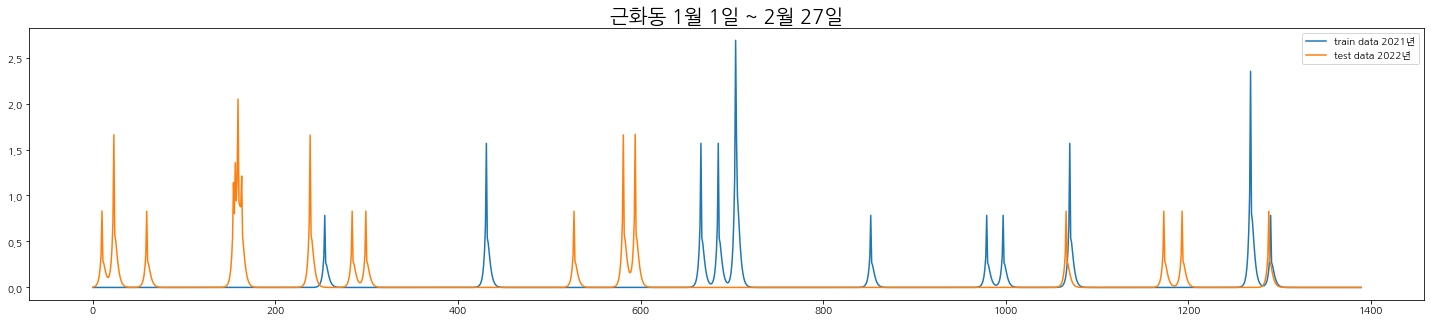

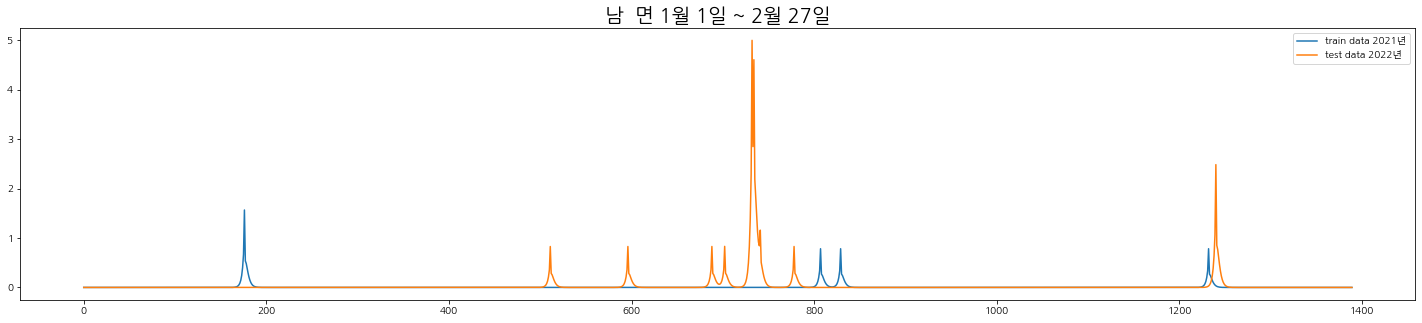

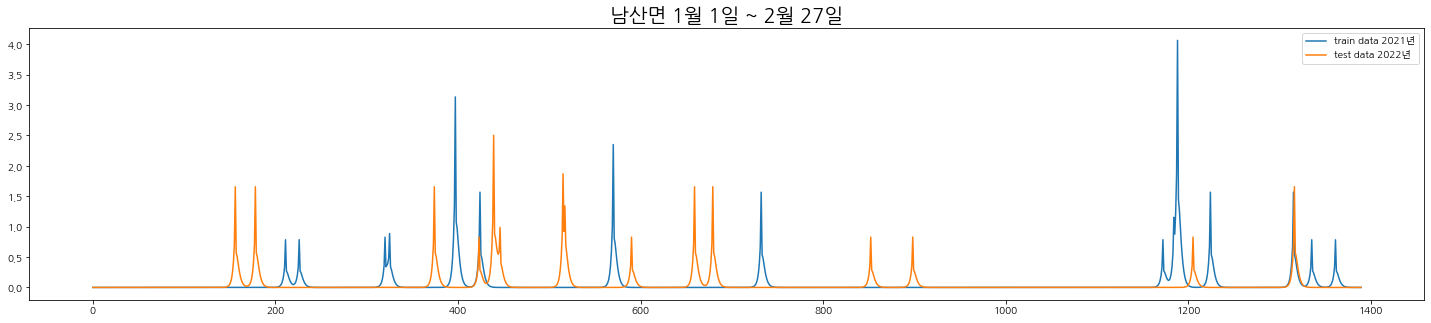

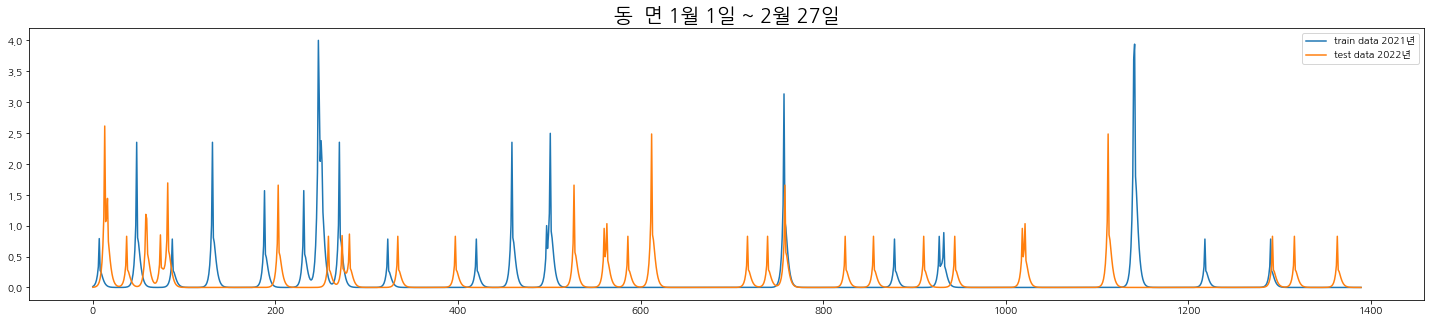

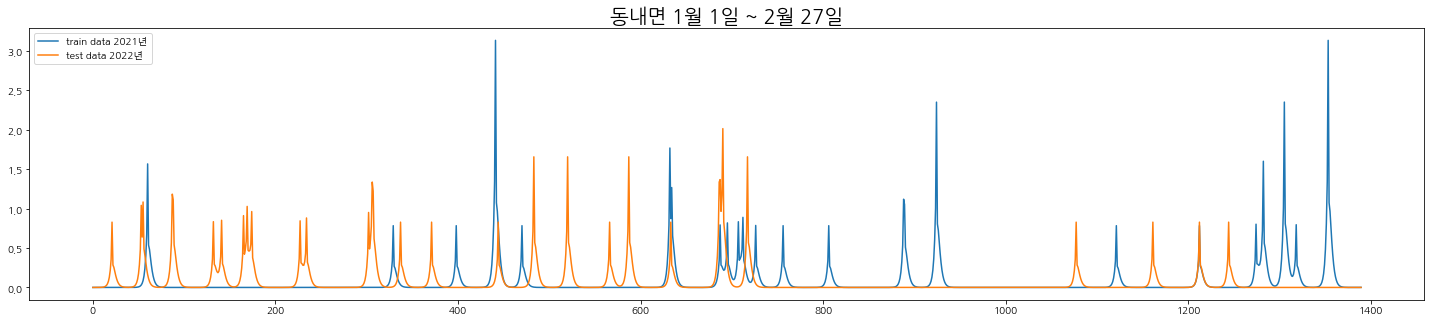

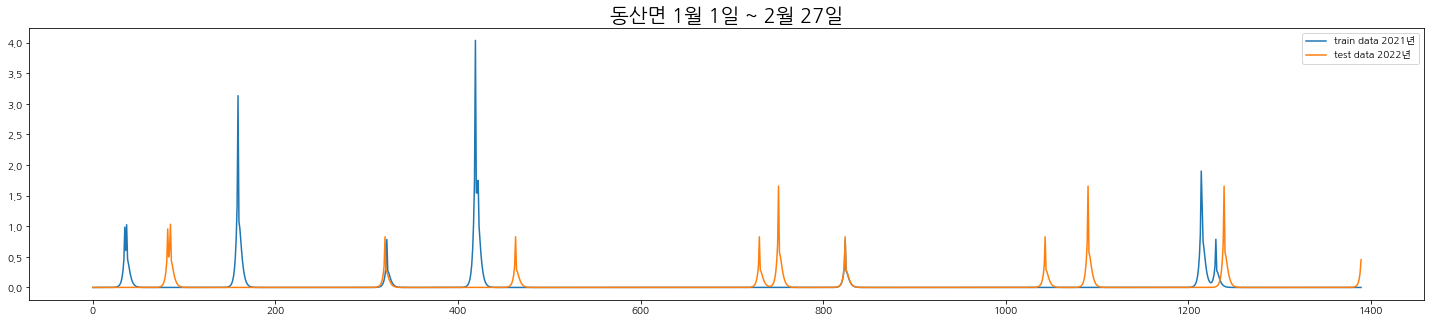

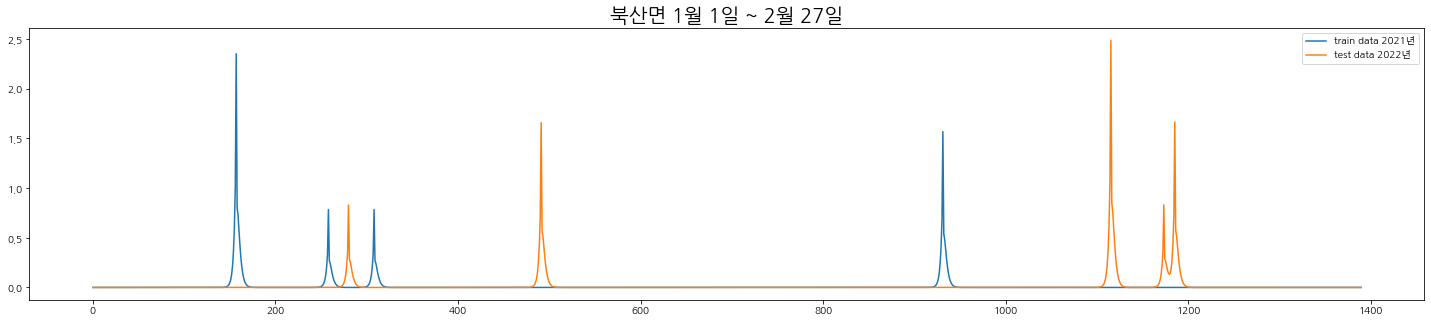

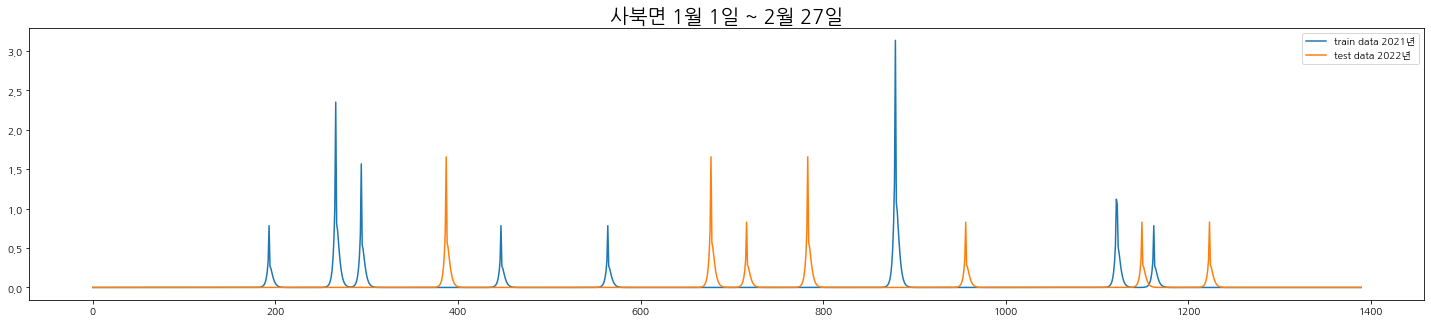

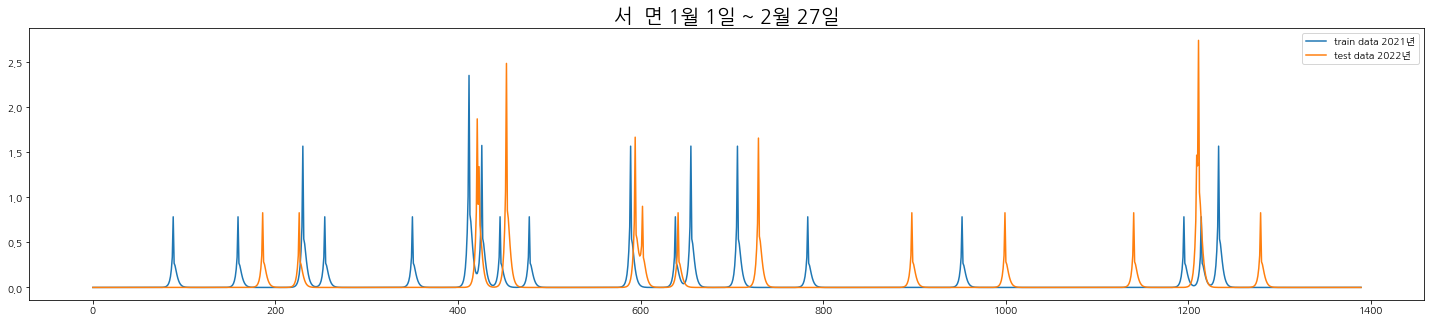

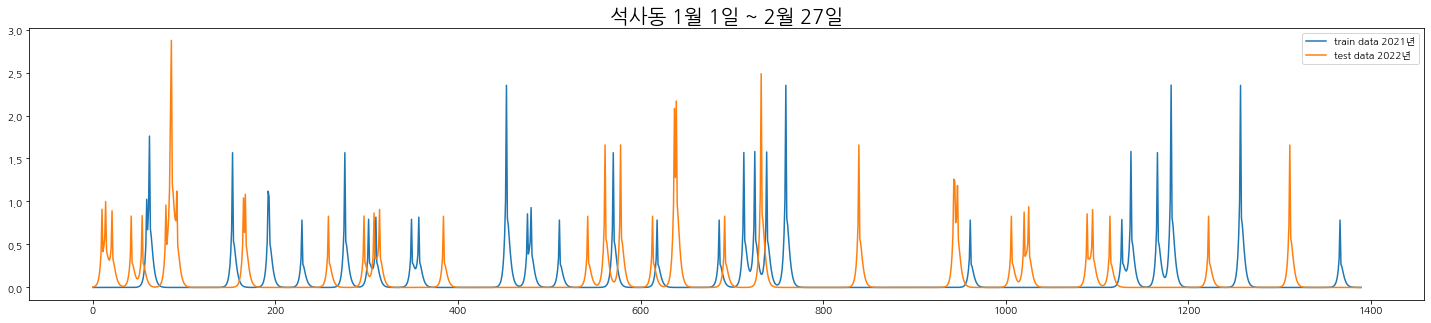

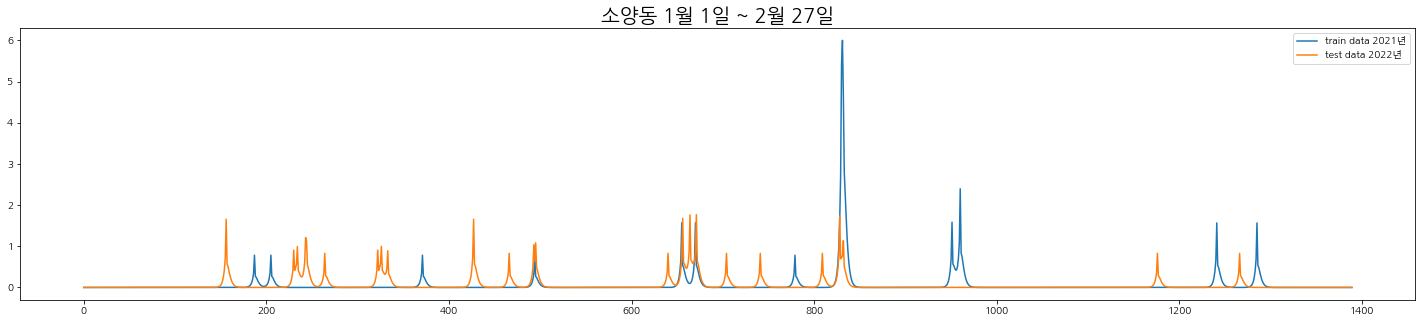

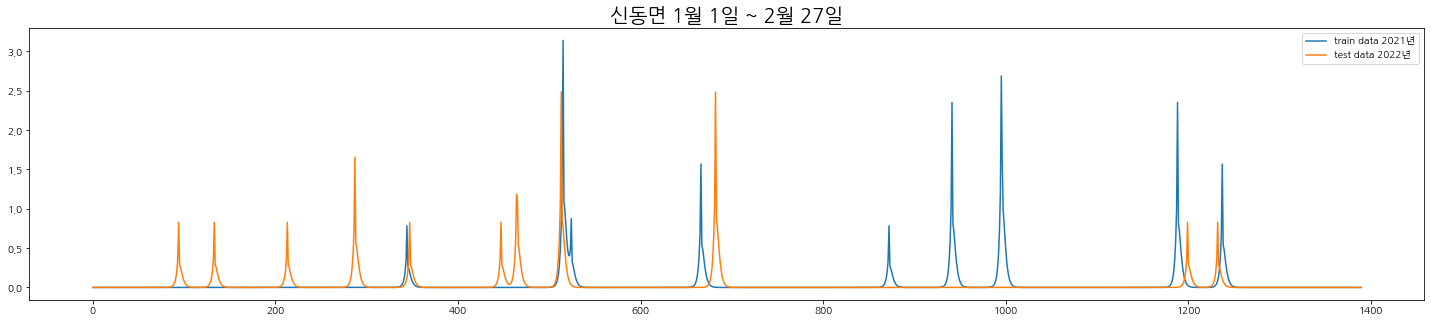

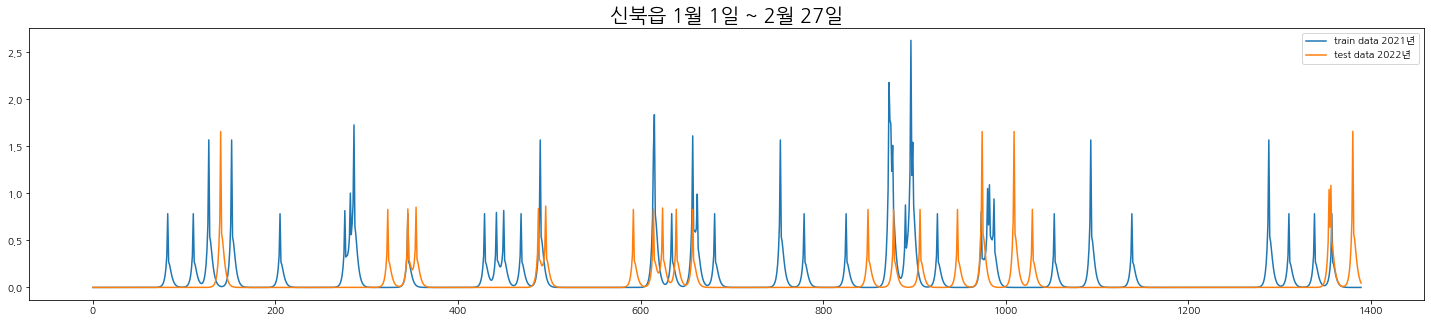

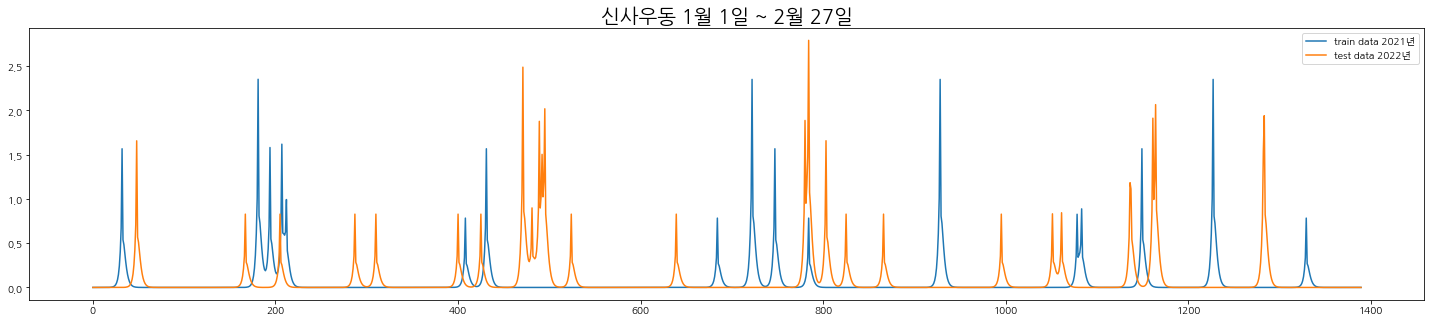

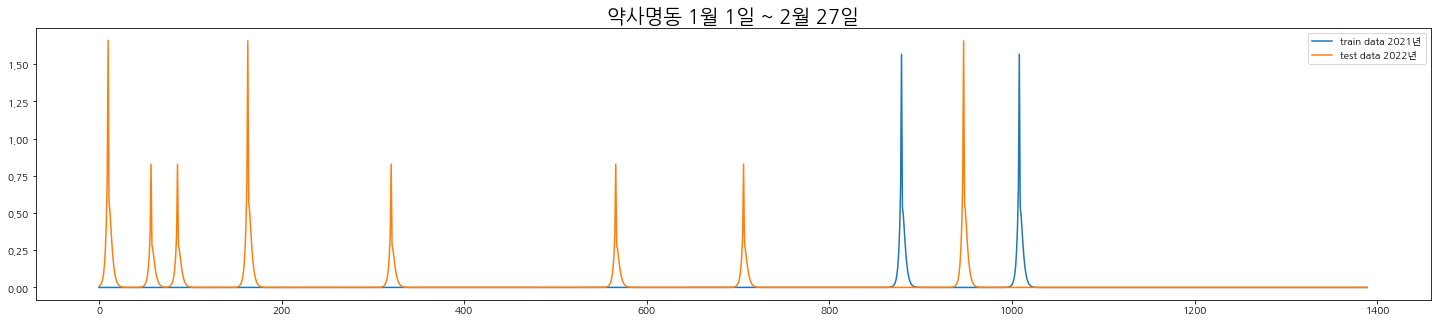

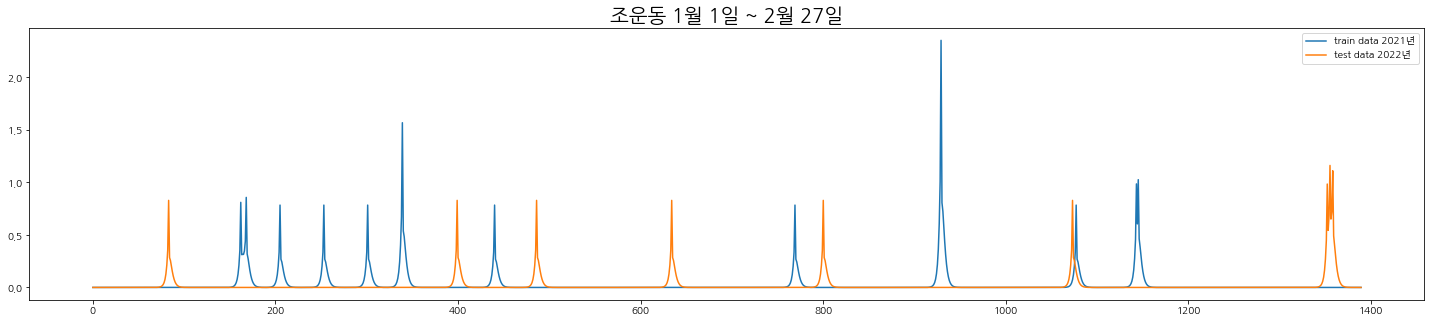

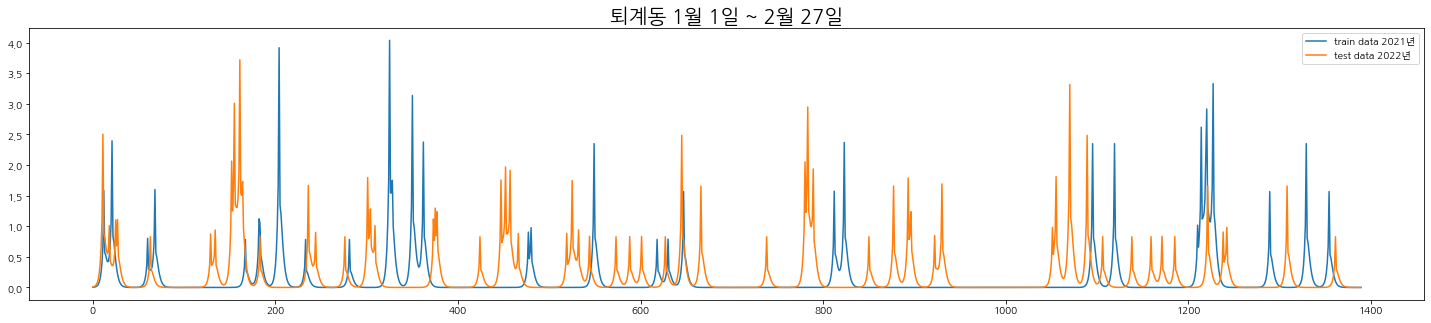

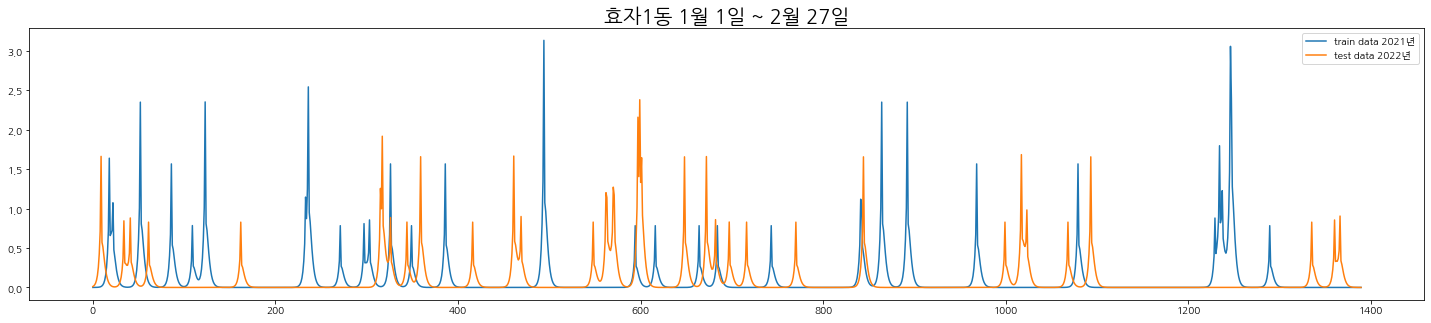

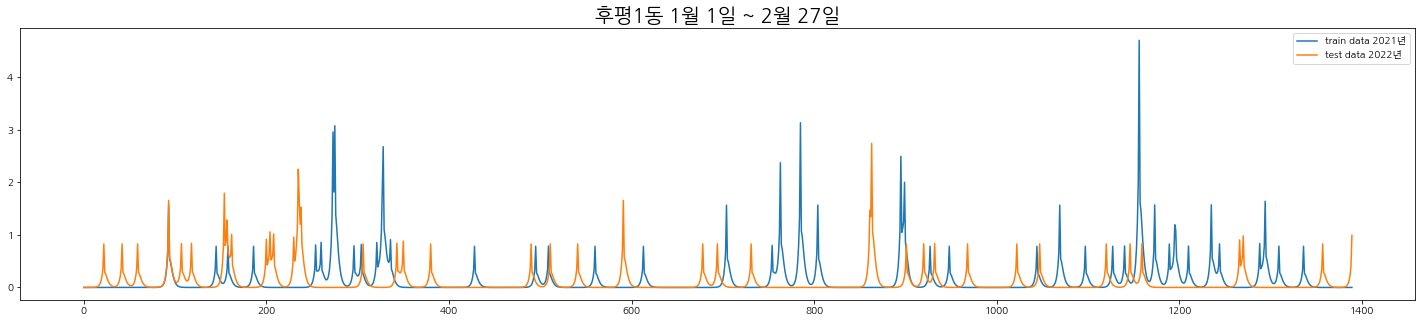

In [56]:
for dong in sorted(train['h_dong'].unique()):
    check_count(train, test, dong)    